# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Construct the URL for the hotels.csv dataset
# Assuming the dataset is in the 'DataSets' folder of the 'is_4487_base' repository
data_url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"

# Import data from the hotels dataset into a dataframe
df_hotels = pd.read_csv(data_url)

# Display the first few rows to confirm it loaded correctly
print("First 5 rows of the hotels dataset:")
df_hotels.head()

First 5 rows of the hotels dataset:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. Stakeholders include: The hotel owner, the hotel manager, booking websites, and potential customers (to name a few)

2. The hotel owner cares about profit generation, more bookings means more money coming in. Hotel managers care about maintaining high guest satisfaction, understanding how many guests they will have at any given time impacts staffing and resoruce distribution. Booking websites care about booking success, they make more money on more transactions. The customer cares about avaialbity of rooms and cost of stay.

3. How can hotel management reduce cancellations to improve hotel occupancy rates by ultizing customer data?




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [2]:
# 1. Summarize the data
print("DataFrame Info:")
df_hotels.info()

print("\nDataFrame Description (Numerical Columns):")
display(df_hotels.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal              

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,7069.000000,1011.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,2015.156104,37.026584,15.515313,1.155040,3.078690,1.864738,0.095279,0.015419,0.077839,0.419715,0.290196,0.238622,200.990946,219.550940,1.019034,86.843614,0.144938,0.613143
std,0.432049,87.584146,0.443661,11.083421,9.025545,1.124304,2.379227,1.198565,0.393858,0.125781,0.267933,2.726546,1.352679,0.630041,80.330753,104.296474,10.137928,53.759940,0.353264,0.835930
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,8.000000,2015.000000,31.000000,7.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,156.000000,135.000000,0.000000,45.000000,0.000000,0.000000
50%,0.000000,48.000000,2015.000000,38.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,71.550000,0.000000,0.000000
75%,0.000000,118.000000,2015.000000,45.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,241.000000,286.000000,0.000000,120.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,13.000000,33.000000,55.000000,10.000000,2.000000,1.000000,26.000000,26.000000,17.000000,468.000000,511.000000,122.000000,508.000000,2.000000,5.000000


In [3]:
# 2. Find the number of Null values
print("\nNumber of Null values per column:")
null_values = df_hotels.isnull().sum()
display(null_values[null_values > 0])


Number of Null values per column:


,0
country,266
agent,2335
company,8393


In [4]:
# 3. Find the number of duplicate rows
num_duplicates = df_hotels.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")


Number of duplicate rows: 1674


### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. Of the missing data, a significant amount of rows are missing the compnay value. Considering the fact that company would indicate who the customer is staying with, from a formatting perspective this may not be a data input error, but a formatting one because not all customers are staying with a company some at there of their own accord.

2. To fix the issue, if we assume that the blank values are meant to indicate no company, a filler value such as 'no company' can be filled in the blanks to make the rest of that submission valid.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

Descriptive statistics for 'adr':


,adr
count,9404.000000
mean,86.843614
std,53.759940
min,-6.380000
25%,45.000000
50%,71.550000
75%,120.600000
max,508.000000


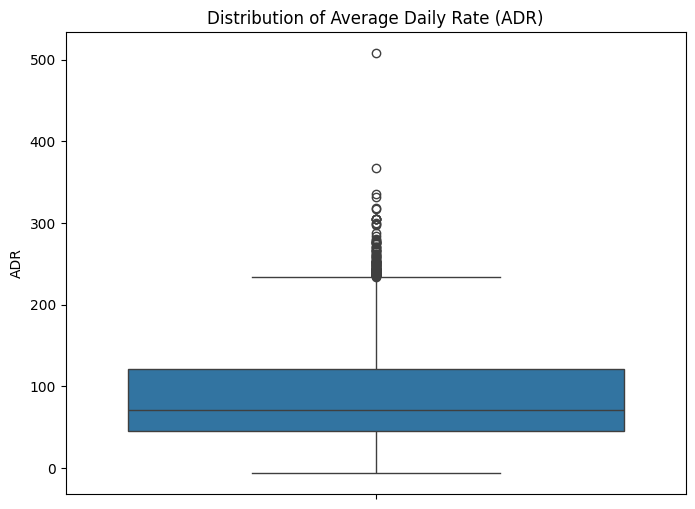


Distribution of 'reservation_status':


,count
reservation_status,
Check-Out,7069
Canceled,2263
No-Show,72


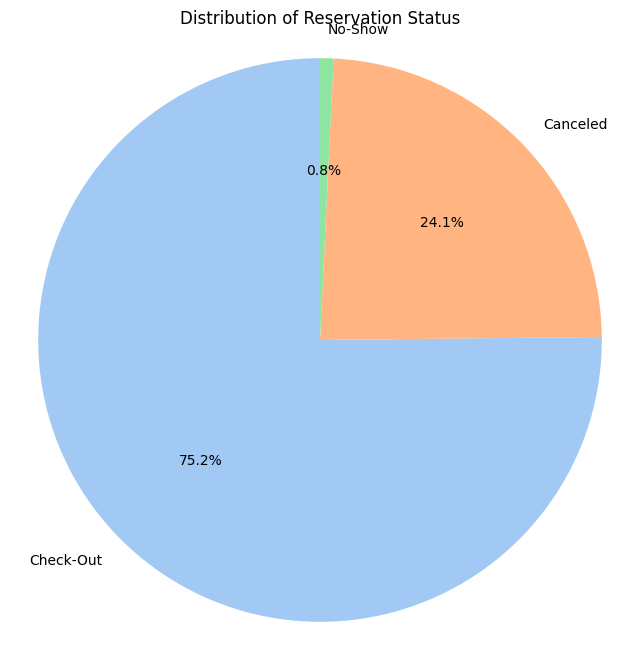


Distribution of 'distribution_channel':


,count
distribution_channel,
TA/TO,6240
Direct,1972
Corporate,1191
Undefined,1


/tmp/ipykernel_851/2696298259.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='viridis')


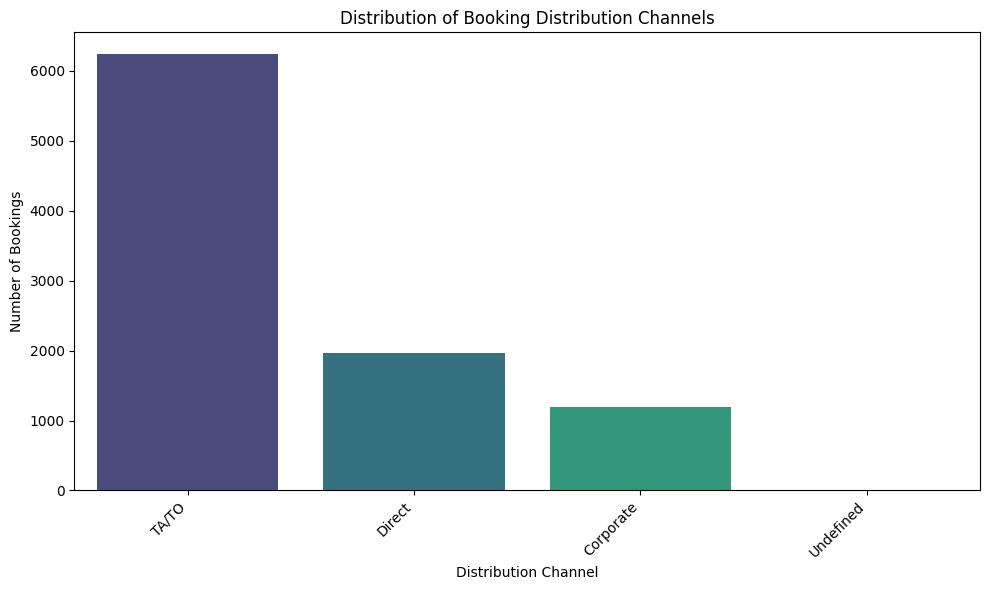

In [5]:
# Univariate Analysis for 'adr' (Average Daily Rate)
print("Descriptive statistics for 'adr':")
display(df_hotels['adr'].describe())
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_hotels['adr'])
plt.title('Distribution of Average Daily Rate (ADR)')
plt.ylabel('ADR')
plt.show()

# Univariate Analysis for 'reservation_status'
print("\nDistribution of 'reservation_status':")
status_counts = df_hotels['reservation_status'].value_counts()
display(status_counts)
plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Reservation Status')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Univariate Analysis for 'distribution_channel'
print("\nDistribution of 'distribution_channel':")
channel_counts = df_hotels['distribution_channel'].value_counts()
display(channel_counts)
plt.figure(figsize=(10, 6))
sns.barplot(x=channel_counts.index, y=channel_counts.values, palette='viridis')
plt.title('Distribution of Booking Distribution Channels')
plt.xlabel('Distribution Channel')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Average Daily Rate** – I used a box plot to display the data. It showed that the average adr was lower than $100, but also indicated a significant amount of outliers that were much higher. Digging deeper it would be interesting to see if these higher adr customers were repeat or single stays.
- **Reservation Status ** –   Instead of looking at cancellation rate, I wanted to see the full picture of guest outcomes. The pie chart indicated that less than 1% of guests no show but that more than 24% cancel their reservations.
- **Distribution Channel**– Looking at a bar chart of the distribution channels was helpful because it allowed me to see how many customers were booking through their companies, which helped to reaffirm some of my thinking from the last reflection where I noted that compnay was often missing data and should have an additional label that acknowledges that they did not book/come with a company.  


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

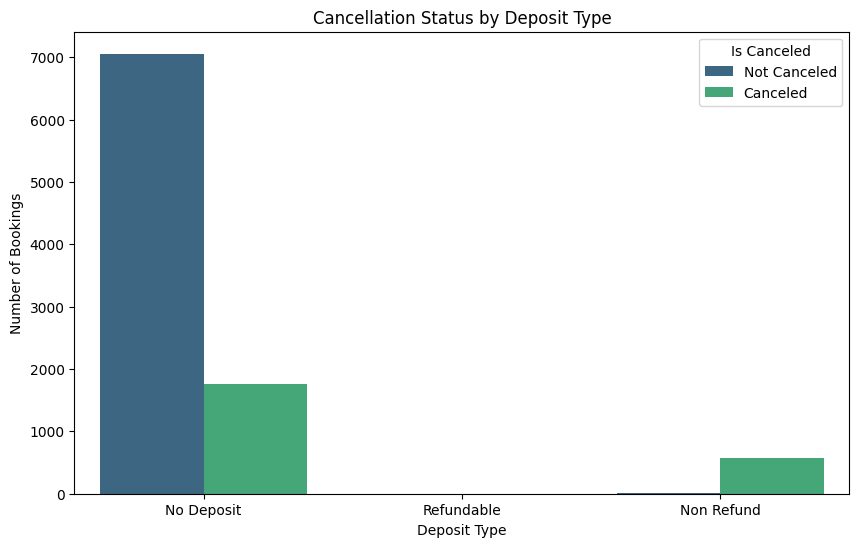

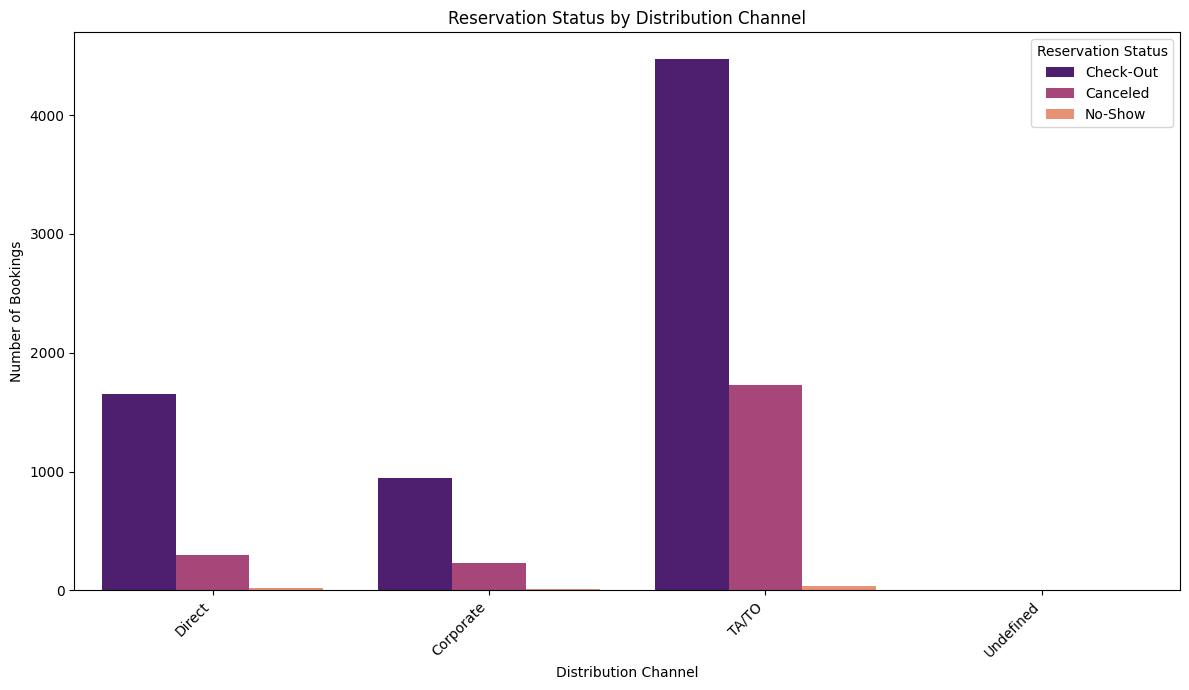

In [6]:
# Relationship 1: is_canceled vs deposit_type
plt.figure(figsize=(10, 6))
sns.countplot(data=df_hotels, x='deposit_type', hue='is_canceled', palette='viridis')
plt.title('Cancellation Status by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Bookings')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

# Relationship 2: reservation_status vs distribution_channel
plt.figure(figsize=(12, 7))
sns.countplot(data=df_hotels, x='distribution_channel', hue='reservation_status', palette='magma')
plt.title('Reservation Status by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reservation Status')
plt.tight_layout()
plt.show()

### Reflection:
1. Relationship 1 – What did you explore and what did you find?
2. Relationship 2 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Cancellation status by deposit** – Using a box plot we looked at whether the cancellation reate was coresponded directly with any of the deposit types to see if there was a line of business resposible for more of the cancellations since that would be a relatively straigthforward business practice to address if that was the cause.
- **Reservation Status by distribution channel ** –   The bar chart here allowed us a better look into the outcomes of each booking mechanism to see if any were directly responsible for the cancelation rate. it appeared that direct and corporate had relatively low cancellation rates, but TA/TO had a much higher cancellation rate (respectively).


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. One insight was that TA/TO cancellations were much higher than direct or company cancellations.
2. This would be impacted by the variety of booking options available, especially since TA/TO was a general category and not broken down by booking agencies.
3. Diagnostic. It would have been more helpful to dig deeper into which booking agencies we partner with have these higher cancellations to determine why they were happening in the first place (ie ease of cancellation, lack of fees, unreasonable promotions, etc).



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. There was a higher rate of cancellation through TA/TO as compared to direct of compnay bookings.

2. Understanding how customers are booking, also means understanding the mechanisms they can use to cancel.

3. I would recommend doing a deeper dive into the booking TA/TO partners we use to understand how their business practices influence the booking and subsequent cancelation of our rooms. Especially seeing if there is a trend across specific partner organizations that can be addressed.

4. This relates to my cutomized learning outcome because it helps me to remember that while every sales channel can help me as an entrepreneur to get exposure, it can also open me up to different streams of cancelation or returns which can complicate my business model as it may take more time to process these refunds and cancellations than it makes in revenue.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [7]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] Converting notebook assignment_05_eda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 529399 bytes to assignment_05_eda.html
